In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from GB84 import variables, rho_m, v,cloud_heights, h_out, phi, f, non_dim_numbers
from kalman_filter import kalman_filter as kf
from scipy import signal
from scipy.stats import pearsonr

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Loading the Data

Choose the time interval for which the model is to be run.

In [2]:
#choose time period of runs
slice_str = "2024-07-16 00:00:00, 2024-07-16 23:59:00"
slice_tuple = tuple(slice_str.split(", "))

The input data used in this model consist of a combined dataset derived from the **Cesar Network surface data** and **Cloudnet MWR profiles** corresponding to Cabauw.

- **Surface variables** include:
  - Surface air temperature
  - Surface pressure
  - Surface dew point temperature

After loading the dataset, only the data corresponding to the **desired time interval** are selected for further analysis.

In [3]:
ground_measurements = xr.open_mfdataset(r'..\data\Cabauw_cesar_surface\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')
var = ['TA002','P0','TD002','RH002']
measurements = ground_measurements[var]
measurements = measurements.dropna(dim='time',how='any')

measurements_used = measurements.sel(time=slice(*slice_tuple))

Storing the time values and the timestep.

In [4]:
time = measurements_used.sel(time=slice(*slice_tuple)).time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

Choose how often then Kalman filter is implemented

In [5]:
kalman_hours = 3
kalman_indices = np.mean(np.round(kalman_hours*3600/dt_seconds)).astype(int)

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance and/or as inputs to the Kalman filter.

In [6]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=time,method='nearest')
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


#### Radiometer LWC 

In [7]:
cabaw = xr.open_mfdataset(r'C:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\data\Cabaw_radiometer\*.nc')
reference_date = np.datetime64("2024-07-01")

# Convert minutes into datetime
#datetime_values = reference_date + measurements.time.astype("timedelta64[m]")
#measurements['time'] = datetime_values

july = cabaw.sel(time=slice('2024-07-01', '2024-08-01'))

### Testing the model

In [8]:
#inputs

#temperature on the ground
T_surf = measurements_used['TA002'].values #[K]


#pressure
p_surf = measurements_used['P0'].values*100  #[Pa]

#dew point temperature
T_d_arr = measurements_used['TD002'].values     #[K]

#state
X = np.zeros(len(T_surf))
X[0] = 0   #initial state in kg/m2
#X = july.lwp.sel(time=measurements_used.time,method='nearest').values
Sigma = np.zeros(len(T_surf))
Sigma[0] = 1 #initial state covariance in kg/m2

In [9]:
#loop for finding the precipitation given the T_0 and p
P = np.zeros(len(T_surf))
P_0 = np.zeros(len(T_surf))
f_arr = np.zeros(len(T_surf))
h_arr = np.zeros(len(T_surf))
for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = variables(T_0, T_d, p_0, obs=False).run()
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
    
    #precipitation in kg/m2/s
    #P_0[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3
    
    #print(phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3600)
    #state without Kalman filter
    P_0[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*3
    P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X[i]
    #print(T_s_up,T_m)
    #state with Kalman filter   
    if i>0:

        if i<(len(T_surf)-1):
            X[i+1] = X[i] + dt_seconds[i]*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X[i])
            Sigma[i+1] = Sigma[i]

        if (((i%kalman_indices)==0)&(i>0)):
            # we assume that we receive a precipitation update every 60mins
            j = i
            print(j)
            
            phi_kf = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()
            h_kf = h_out(v_updr,Z_c).run()[2]
            f_kf = f(T_d,p_0,p_t,T_t,rho,v_updr)
            
            kalman_f = kf(X[i], Sigma[i], dt_seconds[i],h_kf,phi_kf,f_kf,rain_rate[j].values) 
            X[i+1],Sigma[i+1],X_apr = kalman_f.update()

18
[1.94355142] [2.57456825]
36
[1.43383291] [2.42778477]
54
[2.22062755] [2.3787872]
72
[1.79948438] [2.26375898]
90
[4.87558211] [2.37796197]
108
[2.124649] [2.52873235]
126
[0.10440195] [2.77517272]


### Plots and results

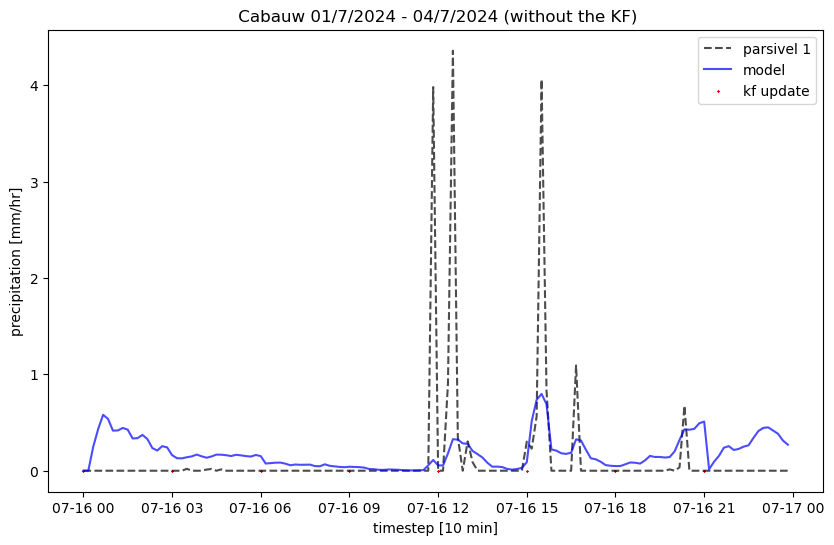

In [11]:
plt.figure(figsize=(10,6))
t_step = np.linspace(0,len(P),len(P))


#plt.plot(t_step,P_0*3600,label='model (steady state)')
plt.plot(time,rain_rate,label='parsivel 1',color='black',alpha=0.7,linestyle='--') 
plt.plot(time,P*3600,label='model',color='blue',alpha=0.7)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.scatter(time[0::kalman_indices],np.zeros((len(rain_rate[0::kalman_indices]))),label='kf update',marker='x',s=0.6,color='red')
plt.xlabel('timestep [10 min]')
plt.title(' Cabauw 01/7/2024 - 04/7/2024 (without the KF)')
plt.ylabel('precipitation [mm/hr]')
plt.legend()
#plt.grid()
plt.show()


## Result analysis

In [684]:
count_prec = np.sum((rain_rate>0.38) & (P*3600 > 0.25))
count_no_prec = np.sum((rain_rate==0) & (P*3600<0.25))
count_model_dubious = np.sum(
    (rain_rate> 0) & (rain_rate <= 0.38) & (P * 3600 < 0.38)) #& (P * 3600 > 0.25)) \
  #+ np.sum((rain_rate == 0) & (P * 3600 < 0.38) )
count_wrong_prec = np.sum((rain_rate==0) & (P*3600 > 0.25)) + np.sum((rain_rate > 0) & (rain_rate <= 0.38) & (P*3600 > 0.38))
count_wrong_zero = np.sum((rain_rate>0.38) & (P*3600 < 0.25))

In [711]:
count_wrong_prec

<xarray.DataArray 'rainfall_rate_32bit' ()> Size: 4B
array(1220)

In [712]:
count_wrong_prec + count_model_dubious + count_prec + count_no_prec + count_wrong_zero

<xarray.DataArray 'rainfall_rate_32bit' ()> Size: 4B
array(4464)

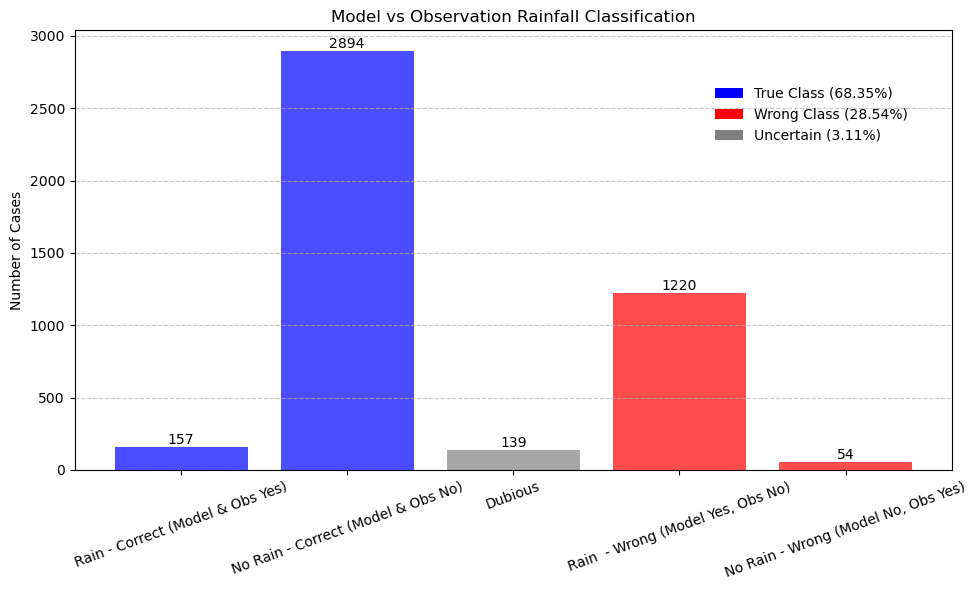

In [706]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# Define labels and values
labels = [
    'Rain - Correct (Model & Obs Yes)',
    'No Rain - Correct (Model & Obs No)',
    'Dubious',
    'Rain  - Wrong (Model Yes, Obs No)',
    'No Rain - Wrong (Model No, Obs Yes)'
]

values = [
    count_prec,
    count_no_prec,
    count_model_dubious,
    
    count_wrong_prec,
    count_wrong_zero
]

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['blue', 'blue', 'gray','red', 'red'],alpha=0.7)

# Add count labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')

legend_elements = [
    Patch(facecolor='blue', label=f'True Class ({(count_prec+count_no_prec)/4464*100:.2f}%)'),
    #Patch(facecolor='blue', label='Correct No Rain'),
    #Patch(facecolor='orange', label='Dubious Cases'),
    Patch(facecolor='red', label=f'Wrong Class ({(count_wrong_prec+count_wrong_zero)/4464*100:.2f}%)'),#label='Correct No Rain'),
    Patch(facecolor='grey', label=f'Uncertain ({(count_model_dubious)/4464*100:.2f}%)')
]

# Add the custom legend at the top
plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.84, 0.9),
           ncol=1, frameon=False)
# Formatting
plt.title("Model vs Observation Rainfall Classification")
plt.ylabel("Number of Cases")
plt.xticks(rotation=20)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


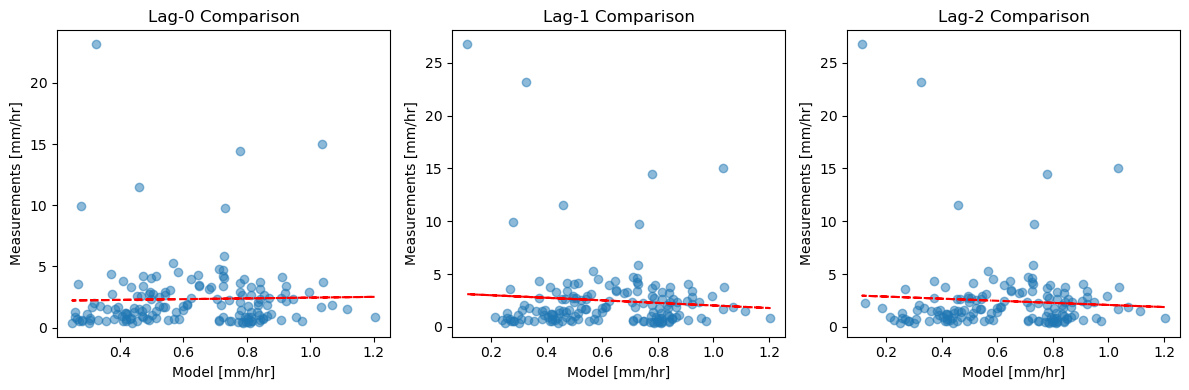

In [750]:
import matplotlib.pyplot as plt

# Prepare indices
indices     = np.where((rain_rate > 0.38) & (P * 3600 > 0.25))
indices_1   = np.where((rain_rate[0:-1] > 0.38) & (P[1:] * 3600 > 0.25))
indices_2   = np.where((rain_rate[0:-2] > 0.38) & (P[2:] * 3600 > 0.25))

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=False)

# Panel 1: Lag 0
z_0 = np.polyfit(P[indices] * 3600, rain_rate[indices], 1)
p_0 = np.poly1d(z_0)
axes[0].scatter(P[indices] * 3600, rain_rate[indices], alpha=0.5)
axes[0].plot(P[indices] * 3600, p_0(P[indices] * 3600), "r--")
axes[0].set_title('Lag-0 Comparison')
axes[0].set_xlabel('Model [mm/hr]')
axes[0].set_ylabel('Measurements [mm/hr]')

# Panel 2: Lag -1 (measurement leads model by 1)
z_1 = np.polyfit(P[indices_1] * 3600, rain_rate[indices_1], 1)
p_1 = np.poly1d(z_1)
axes[1].scatter(P[indices_1] * 3600, rain_rate[0:-1][indices_1], alpha=0.5)
axes[1].plot(P[indices_1] * 3600, p_1(P[indices_1] * 3600), "r--")
axes[1].set_title('Lag-1 Comparison')
axes[1].set_xlabel('Model [mm/hr]')
axes[1].set_ylabel('Measurements [mm/hr]')

# Panel 3: Lag +1 (model leads measurement by 1)
z_2 = np.polyfit(P[indices_2] * 3600, rain_rate[indices_2], 1)
p_2 = np.poly1d(z_2)
axes[2].scatter(P[indices_2] * 3600, rain_rate[0:-2][indices_2], alpha=0.5)
axes[2].plot(P[indices_2] * 3600, p_2(P[indices_2] * 3600), "r--")
axes[2].set_title('Lag-2 Comparison')
axes[2].set_xlabel('Model [mm/hr]')
axes[2].set_ylabel('Measurements [mm/hr]')

# Optional: consistent y-axis or limits
# for ax in axes:
#     ax.set_ylim(0, 10)
#     ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()

#plt.ylim(0,10)

In [754]:
pearsonr((rain_rate>0.38),(P*3600>0.25))

PearsonRResult(statistic=0.20650359018880848, pvalue=3.429520934379956e-44)

In [570]:
count_no_prec

<xarray.DataArray 'rainfall_rate_32bit' ()> Size: 4B
array(2780)

In [613]:
correlation = signal.correlate(rain_rate, P*3600, mode="full")

lags = signal.correlation_lags(rain_rate.size, P.size, mode="full")

lag = lags[np.argmax(correlation)]

In [721]:
print(np.array(correlation))

[ 1.39652756e-07  4.40390071e-07  7.50952897e-07 ... -1.12172320e-06
 -1.19532343e-06 -1.22798479e-06]


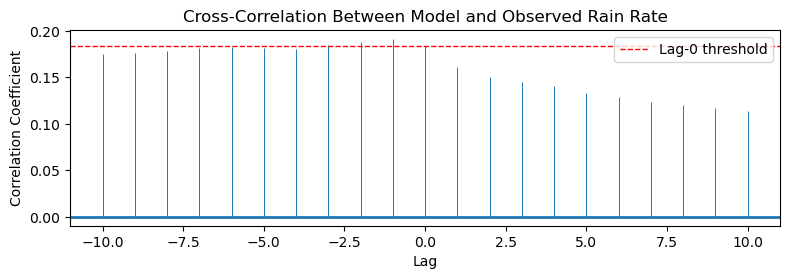

In [714]:
import matplotlib.pyplot as plt

# Create the figure and axis
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(211)

# Cross-correlation
ax1.xcorr(rain_rate, P * 3600, usevlines=True,
          maxlags=10, normed=True,
          lw=2, linewidth=0.7)

# Horizontal reference line
ax1.axhline(y=0.18337568, color='r', linestyle='dashed', linewidth=1, label='Lag-0 threshold')

# Axis labels and title
ax1.set_title('Cross-Correlation Between Model and Observed Rain Rate')
ax1.set_xlabel('Lag')
ax1.set_ylabel('Correlation Coefficient')

# Add legend
ax1.legend(loc='upper right')

# Optional: adjust layout
plt.tight_layout()
plt.show()


ValueError: x and y must have same first dimension, but have shapes (4464,) and (432,)

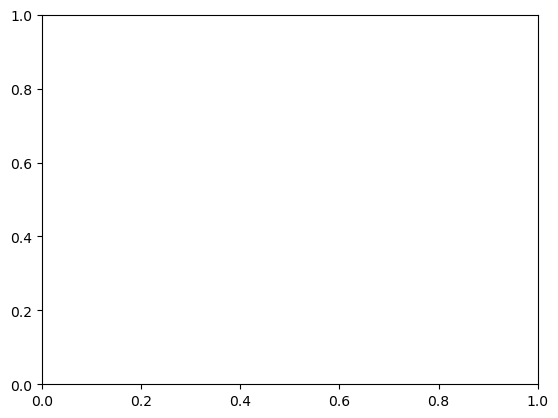

In [512]:
plt.plot(t_step,rain_rate.sel(time=slice('2024-07-05 00:00:00', '2024-07-07 23:59:00')),label='observation')

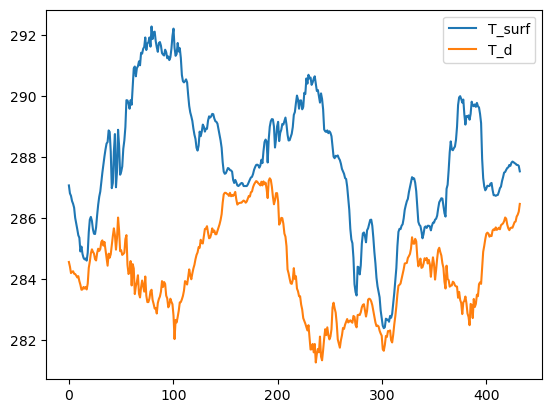

In [ ]:
plt.plot(t_step,T_surf,label='T_surf')
plt.plot(t_step,T_d_arr,label='T_d')
plt.legend()

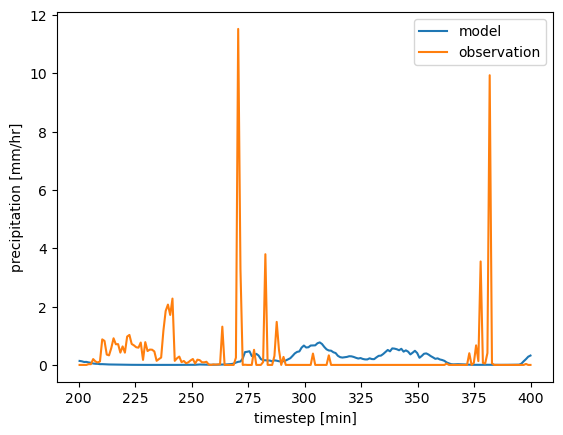

In [ ]:
#zooming when no rain is observed

t_step = np.linspace(0,len(P),len(P))
plt.plot(t_step[200:400],P[200:400]*3600,label='model')
plt.plot(t_step[200:400],rain_rate.sel(time=slice('2024-07-05 00:00:00', '2024-07-07 23:59:00'))[200:400],label='observation')
plt.legend()
plt.xlabel('timestep [min]')
plt.ylabel('precipitation [mm/hr]')
plt.show()


Text(0, 0.5, 'liquid water [kg/m^2]')

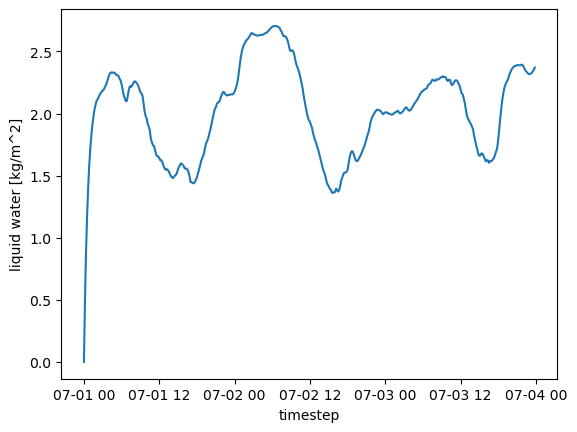

In [ ]:
#state evolution

plt.plot(measurements_used.time,X)
#plt.plot(july.time,july.lwp)
plt.xlabel('timestep')
plt.ylabel('liquid water [kg/m^2]')

Text(0, 0.5, 'average hourly precipitation (mm/hr)')

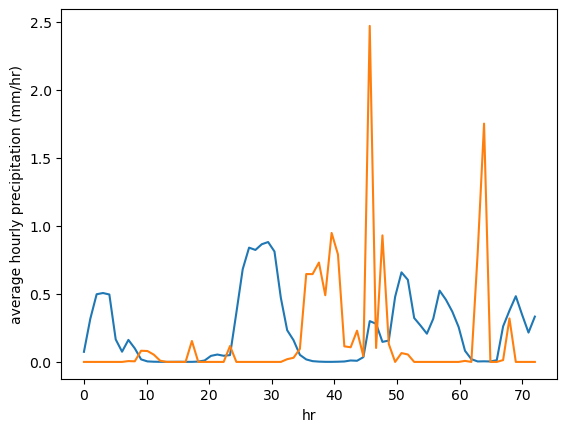

In [ ]:
Pmeas = rain_rate.sel(time=slice('2024-07-05 00:00:00', '2024-07-07 23:59:00'))
averages_P = [np.mean(P[i:i+6]) for i in range(0, len(P), 6)]
averages_Pmeas=[np.mean(Pmeas[i:i+6]) for i in range(0, len(P), 6)]
t_hr = np.linspace(0,len(averages_P),len(averages_P))

plt.plot(t_hr,np.array(averages_P)*3600,label='model (Kf)')   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(t_hr,averages_Pmeas,label='observation')
plt.xlabel('hr')
plt.ylabel('average hourly precipitation (mm/hr)')

In [ ]:
v_arr = np.zeros(len(T_surf))
O_b_arr = np.zeros(len(T_surf))
O_h_arr = np.zeros(len(T_surf))
I_arr = np.zeros(len(T_surf))

for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = variables(T_0, T_d, p_0, obs=False).run()
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)*5
    v_arr[i] = v_updr
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
    print(non_dim_numbers(v_updr)[1])
    O_b_arr[i] = O_b*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    O_h_arr[i] = O_t*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    I_arr[i] = f(T_d,p_0,p_t,T_t,rho,v_updr)
     


2.861678495997993
2.8592679795489375
2.850955763799069
2.8557801536540404
2.858272230481497
2.856799343946523
2.8620726801773095
2.8628237671576504
2.8632645505356322
2.868506832716003
2.862414917763598
2.8643715629796858
2.8542271062454567
2.8587080445089583
2.8646032444141807
2.863100768499363
2.8649348069522125
2.8623637577984007
2.8669003691811596
2.879391186295834
2.881746501465455
2.8926424873080445
2.900806511249578
2.9019186702723085
2.9015168228761086
2.893482700136438
2.8879430166321924
2.892201492563092
2.8928219548620437
2.885132426389541
2.884947573766136
2.8900008840880274
2.8871039595394357
2.874588056360593
2.875553803920708
2.859893041536245
2.843920264695285
2.831480912221156
2.8428005873000686
2.8377312249308804
2.8544746268505246
2.890033052252707
2.899957783208608
2.893273838166988
2.8729558350203215
2.8823520108758114
2.8906499002718133
2.8966426228124753
2.886674668351837
2.8730779113001677
2.8727675204546252
2.8627670001225702
2.8538635253049933
2.85084319709035

KeyboardInterrupt: 

Text(0, 0.5, 'updraft velocity [m/s]')

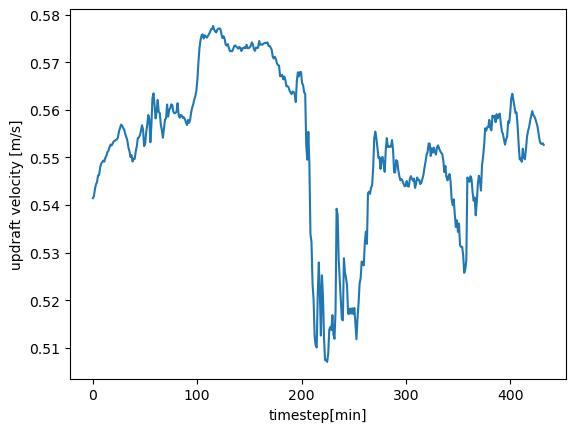

In [ ]:
plt.plot(t_step,v_arr)
plt.xlabel('timestep[min]')
plt.ylabel('updraft velocity [m/s]')

Text(0.5, 1.0, 'Cloud Fluxes')

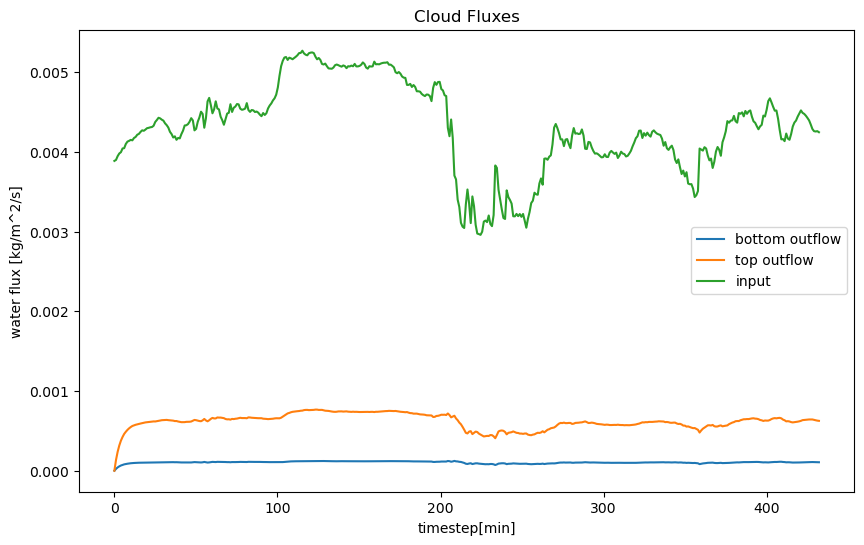

In [ ]:
A = np.zeros(30000)
#for i in range(0,3000):
    #if measurements['rain_rate'].values[7000+i]>0:
        #A[i] = t_step[i]
    #else:
        #A[i] = 0
    

plt.figure(figsize=(10,6))
plt.plot(t_step,O_b_arr,label='bottom outflow')
plt.plot(t_step,O_h_arr,label='top outflow')
plt.plot(t_step,I_arr,label='input')
plt.xlabel('timestep[min]')
plt.ylabel('water flux [kg/m^2/s]')
#plt.vlines(A,0,0.005,alpha=0.1,color='red')
plt.legend()
plt.title('Cloud Fluxes')

In [ ]:
O_b

0.3511910208066662

In [ ]:
X[i]*non_dim_numbers(v_updr)[0]/Z_c

array([0.00030251])

In [ ]:
T_t

array([246.24067734])